In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from torchvision.models import ResNet18_Weights
from tqdm.notebook import tqdm

In [2]:
import torchvision
from torch.utils.data import DataLoader, Dataset, random_split
from matplotlib import pyplot as plt
import random
import os
import math
from pprint import pprint

In [3]:
seed = 0
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
random.seed(seed)
np.random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)

# Dataset Creation

spurious correlation:
- shape: 75%, color: 85%
- shape: 75%, color: 90%
- shape: 75%, color: 95%

In [4]:
TOTAL = 40_000
s1 = 0.95
s2 = 0.75
c1_m_red = c2_fm_green = math.ceil(TOTAL * s1 * s2 * 0.5)
c1_m_green = c2_fm_red = int(TOTAL * s2 * (1 - s1) * 0.5)
c1_fm_red = c2_m_green = math.ceil(TOTAL * s1 * (1 - s2) * 0.5)
c1_fm_green = c2_m_red = int(TOTAL * (1 - s1) * (1 - s2) * 0.5)

In [5]:
print(c1_m_red,
      c1_m_green,
      c1_fm_red,
      c1_fm_green,
      c2_m_red,
      c2_m_green,
      c2_fm_red,
      c2_fm_green,
      sep='\n')

14250
750
4750
250
250
4750
750
14250


In [6]:
def color_grayscale_arr(arr, red=True):
  """Converts grayscale image to either red or green"""
  assert arr.ndim == 2
  dtype = arr.dtype
  h, w = arr.shape
  arr = np.reshape(arr, [1, h, w])
  if red:
    arr = np.concatenate([arr,
                          np.zeros((2, h, w), dtype=dtype)], axis=0)
  else:
    arr = np.concatenate([np.zeros((1, h, w), dtype=dtype),
                          arr,
                          np.zeros((1, h, w), dtype=dtype)], axis=0)
  return arr

In [7]:
def keep_only_lbls(dataset, lbls):
  lbls = {lbl: i for i, lbl in enumerate(lbls)}
  final_X, final_Y = [], []
  for x, y in dataset:
    if y in lbls:
      final_X.append(x)
      final_Y.append(lbls[y])
  X = torch.stack(final_X)
  Y = torch.tensor(final_Y).float().view(-1,1)
  return X, Y

In [8]:
mnist_transform = torchvision.transforms.Compose([
          torchvision.transforms.ToTensor(), 
          torchvision.transforms.Normalize(mean=0.485,
                                           std=0.229),
        ])
mnist_train = torchvision.datasets.MNIST('./data/mnist/', train=True, download=True, transform=mnist_transform)
X_mnist, _ = keep_only_lbls(mnist_train, lbls=[0, 1, 2, 3])

In [9]:
X_mnist.shape

torch.Size([24754, 1, 28, 28])

In [10]:
X_mnist.min(), X_mnist.mean(), X_mnist.max()

(tensor(-2.1179), tensor(-1.5367), tensor(2.2489))

In [11]:
fmnist_train = torchvision.datasets.FashionMNIST('./data/fashion_mnist/', train=True, download=True, transform=mnist_transform)

In [12]:
X_fmnist, _ = keep_only_lbls(fmnist_train, lbls=[0, 3, 4, 6])
X_fmnist.shape

torch.Size([24000, 1, 28, 28])

In [13]:
X_fmnist.min(), X_fmnist.mean(), X_fmnist.max()

(tensor(-2.1179), tensor(-0.6969), tensor(2.2489))

In [14]:
red_mnist, red_fmnist, green_mnist, green_fmnist = [], [], [], []

for idx, img in enumerate(X_mnist):
    img = color_grayscale_arr(img.squeeze().numpy(), red=True)
    img = np.pad(img, ((0, 0), (2, 2), (2, 2)), constant_values=0)
    red_mnist.append(torch.tensor(img))
red_mnist = torch.stack(red_mnist)
for idx, img in enumerate(X_mnist):
    img = color_grayscale_arr(img.squeeze().numpy(), red=False)
    img = np.pad(img, ((0, 0), (2, 2), (2, 2)), constant_values=0)
    green_mnist.append(torch.tensor(img))
green_mnist = torch.stack(green_mnist)

for idx, img in enumerate(X_fmnist):
    img = color_grayscale_arr(img.squeeze().numpy(), red=True)
    img = np.pad(img, ((0, 0), (2, 2), (2, 2)), constant_values=0)
    red_fmnist.append(torch.tensor(img))
red_fmnist = torch.stack(red_fmnist)
for idx, img in enumerate(X_fmnist):
    img = color_grayscale_arr(img.squeeze().numpy(), red=False)
    img = np.pad(img, ((0, 0), (2, 2), (2, 2)), constant_values=0)
    green_fmnist.append(torch.tensor(img))
green_fmnist = torch.stack(green_fmnist)

In [15]:
red_mnist.shape, green_mnist.shape, red_fmnist.shape, green_fmnist.shape

(torch.Size([24754, 3, 32, 32]),
 torch.Size([24754, 3, 32, 32]),
 torch.Size([24000, 3, 32, 32]),
 torch.Size([24000, 3, 32, 32]))

In [16]:
idx = torch.randperm(red_mnist.shape[0])
red_mnist_0_idx = idx[:c1_m_red]
red_mnist_4_idx = idx[c1_m_red:c1_m_red+c2_m_red]
red_mnist_0 = red_mnist[red_mnist_0_idx]
red_mnist_4 = red_mnist[red_mnist_4_idx]
red_mnist_0.shape, red_mnist_4.shape

(torch.Size([14250, 3, 32, 32]), torch.Size([250, 3, 32, 32]))

In [17]:
idx = torch.randperm(green_mnist.shape[0])
green_mnist_1_idx = idx[:c1_m_green]
green_mnist_5_idx = idx[c1_m_green:c1_m_green+c2_m_green]
green_mnist_1 = green_mnist[green_mnist_1_idx]
green_mnist_5 = green_mnist[green_mnist_5_idx]
green_mnist_1.shape, green_mnist_5.shape

(torch.Size([750, 3, 32, 32]), torch.Size([4750, 3, 32, 32]))

In [18]:
idx = torch.randperm(red_fmnist.shape[0])
red_fmnist_2_idx = idx[:c1_fm_red]
red_fmnist_6_idx = idx[c1_fm_red:c1_fm_red+c2_fm_red]
red_fmnist_2 = red_fmnist[red_fmnist_2_idx]
red_fmnist_6 = red_fmnist[red_fmnist_6_idx]
red_fmnist_2.shape, red_fmnist_6.shape

(torch.Size([4750, 3, 32, 32]), torch.Size([750, 3, 32, 32]))

In [19]:
idx = torch.randperm(green_fmnist.shape[0])
green_fmnist_3_idx = idx[:c1_fm_green]
green_fmnist_7_idx = idx[c1_fm_green:c1_fm_green+c2_fm_green]
green_fmnist_3 = green_fmnist[green_fmnist_3_idx]
green_fmnist_7 = green_fmnist[green_fmnist_7_idx]
green_fmnist_3.shape, green_fmnist_7.shape

(torch.Size([250, 3, 32, 32]), torch.Size([14250, 3, 32, 32]))

In [20]:
cifar_transform = torchvision.transforms.Compose([
          torchvision.transforms.ToTensor(), 
          torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                           std=[0.229, 0.224, 0.225]),
        ])
cifar_train = torchvision.datasets.CIFAR10('./data/cifar10/', train=True, download=True, transform=cifar_transform)
X_c_cars, _ = keep_only_lbls(cifar_train, lbls=[0, 1, 8, 9])
X_c_animals, _ = keep_only_lbls(cifar_train, lbls=[3, 4, 5, 7])
X_c_cars.shape, X_c_animals.shape

Files already downloaded and verified


(torch.Size([20000, 3, 32, 32]), torch.Size([20000, 3, 32, 32]))

In [21]:
X_c_cars.min(), X_c_cars.mean(), X_c_cars.max()

(tensor(-2.1179), tensor(0.2564), tensor(2.6400))

In [22]:
X_c_animals.min(), X_c_animals.mean(), X_c_animals.max()

(tensor(-2.1179), tensor(0.0274), tensor(2.6400))

In [23]:
X_c_cars_0 = X_c_cars[:c1_m_red]
X_c_cars_1 = X_c_cars[c1_m_red:c1_m_red+c1_m_green]
X_c_cars_2 = X_c_cars[c1_m_red+c1_m_green:c1_m_red+c1_m_green+c1_fm_red]
X_c_cars_3 = X_c_cars[c1_m_red+c1_m_green+c1_fm_red:]
X_c_cars_0.shape, X_c_cars_1.shape, X_c_cars_2.shape, X_c_cars_3.shape

(torch.Size([14250, 3, 32, 32]),
 torch.Size([750, 3, 32, 32]),
 torch.Size([4750, 3, 32, 32]),
 torch.Size([250, 3, 32, 32]))

In [24]:
X_c_animals_7 = X_c_animals[:c2_fm_green]
X_c_animals_6 = X_c_animals[c2_fm_green:c2_fm_green+c2_fm_red]
X_c_animals_5 = X_c_animals[c2_fm_green+c2_fm_red:c2_fm_green+c2_fm_red+c2_m_green]
X_c_animals_4 = X_c_animals[c2_fm_green+c2_fm_red+c2_m_green:]
X_c_animals_7.shape, X_c_animals_6.shape, X_c_animals_5.shape, X_c_animals_4.shape

(torch.Size([14250, 3, 32, 32]),
 torch.Size([750, 3, 32, 32]),
 torch.Size([4750, 3, 32, 32]),
 torch.Size([250, 3, 32, 32]))

In [25]:
group_0_X = torch.cat((X_c_cars_0, red_mnist_0), dim=2)
group_0_Y = torch.zeros(len(group_0_X))
group_0_G = torch.tensor([0] * len(group_0_X))
group_0_X.shape

torch.Size([14250, 3, 64, 32])

In [26]:
group_1_X = torch.cat((X_c_cars_1, green_mnist_1), dim=2)
group_1_Y = torch.zeros(len(group_1_X))
group_1_G = torch.tensor([1] * len(group_1_X))
group_1_X.shape

torch.Size([750, 3, 64, 32])

In [27]:
group_2_X = torch.cat((X_c_cars_2, red_fmnist_2), dim=2)
group_2_Y = torch.zeros(len(group_2_X))
group_2_G = torch.tensor([2] * len(group_2_X))
group_2_X.shape

torch.Size([4750, 3, 64, 32])

In [28]:
group_3_X = torch.cat((X_c_cars_3, green_fmnist_3), dim=2)
group_3_Y = torch.zeros(len(group_3_X))
group_3_G = torch.tensor([3] * len(group_3_X))
group_3_X.shape

torch.Size([250, 3, 64, 32])

In [29]:
group_4_X = torch.cat((X_c_animals_4, red_mnist_4), dim=2)
group_4_Y = torch.ones(len(group_4_X))
group_4_G = torch.tensor([4] * len(group_4_X))
group_4_X.shape

torch.Size([250, 3, 64, 32])

In [30]:
group_5_X = torch.cat((X_c_animals_5, green_mnist_5), dim=2)
group_5_Y = torch.ones(len(group_5_X))
group_5_G = torch.tensor([5] * len(group_5_X))
group_5_X.shape

torch.Size([4750, 3, 64, 32])

In [31]:
group_6_X = torch.cat((X_c_animals_6, red_fmnist_6), dim=2)
group_6_Y = torch.ones(len(group_6_X))
group_6_G = torch.tensor([6] * len(group_6_X))
group_6_X.shape

torch.Size([750, 3, 64, 32])

In [32]:
group_7_X = torch.cat((X_c_animals_7, green_fmnist_7), dim=2)
group_7_Y = torch.ones(len(group_7_X))
group_7_G = torch.tensor([7] * len(group_7_X))
group_7_X.shape

torch.Size([14250, 3, 64, 32])

In [33]:
X = torch.cat((group_0_X, group_1_X, group_2_X, group_3_X, group_4_X, group_5_X, group_6_X, group_7_X))
Y = torch.cat((group_0_Y, group_1_Y, group_2_Y, group_3_Y, group_4_Y, group_5_Y, group_6_Y, group_7_Y))
G = torch.cat((group_0_G, group_1_G, group_2_G, group_3_G, group_4_G, group_5_G, group_6_G, group_7_G))
X.shape, Y.shape, G.shape

(torch.Size([40000, 3, 64, 32]), torch.Size([40000]), torch.Size([40000]))

In [34]:
Y.unique(return_counts=True), G.unique(return_counts=True)

((tensor([0., 1.]), tensor([20000, 20000])),
 (tensor([0, 1, 2, 3, 4, 5, 6, 7]),
  tensor([14250,   750,  4750,   250,   250,  4750,   750, 14250])))

In [35]:
torch.save(X, 'cifar_cmnist_fmnist_dominoe_X_9575.pt')
torch.save(Y, 'cifar_cmnist_fmnist_dominoe_Y_9575.pt')
torch.save(G, 'cifar_cmnist_fmnist_dominoe_G_9575.pt')

In [ ]:
invTrans = torchvision.transforms.Compose([ torchvision.transforms.Normalize(mean = [ 0., 0., 0. ],
                                                     std = [ 1/0.229, 1/0.224, 1/0.225 ]),
                                            torchvision.transforms.Normalize(mean = [ -0.485, -0.456, -0.406 ],
                                                     std = [ 1., 1., 1. ]),
                               ])

for i in [0, 13500, 15000, 19500, 20000, 20500, 25000, 26500]:
    # plt.imshow(invTrans(X[i]).permute(1,2,0))
    X[i][:, :32, :] = (X[i][:, :32, :]-X[i][:, :32, :].min())/(X[i][:, :32, :].max()-X[i][:, :32, :].min())
    # X[i][:, 32:, :] = (X[i][:, 32:, :]-X[i][:, 32:, :].min())/(X[i][:, 32:, :].max()-X[i][:, 32:, :].min())
    plt.imshow(X[i].permute(1,2,0), cmap='gray')
    plt.axis('off')
    plt.show()

In [37]:
X.shape, Y.shape

(torch.Size([40000, 3, 64, 32]), torch.Size([40000]))

In [38]:
dataset = TensorDataset(X, Y.long(), G.long())

In [39]:
train_dataset, lastlayer_dataset, val_dataset, test_dataset = random_split(dataset, [0.25, 0.25, 0.25, 0.25], generator=torch.Generator().manual_seed(42))

In [40]:
len(train_dataset), len(lastlayer_dataset), len(val_dataset), len(test_dataset)

(10000, 10000, 10000, 10000)

In [41]:
import pickle
with open('train_indices_9575.pkl', 'wb') as f:
    pickle.dump(train_dataset.indices, f)
with open('lastlayer_indices_9575.pkl', 'wb') as f:
    pickle.dump(lastlayer_dataset.indices, f)
with open('val_indices_9575.pkl', 'wb') as f:
    pickle.dump(val_dataset.indices, f)
with open('test_indices_9575.pkl', 'wb') as f:
    pickle.dump(test_dataset.indices, f)

# Loading dataset

In [89]:
EIIL = False

In [90]:
import pickle
with open('train_indices_07095.pkl', 'rb') as f:
    tr = pickle.load(f)
with open('lastlayer_indices_07095.pkl', 'rb') as f:
    ll = pickle.load(f)
with open('val_indices_07095.pkl', 'rb') as f:
    val = pickle.load(f)
with open('test_indices_07095.pkl', 'rb') as f:
    te = pickle.load(f)
X = torch.load('cifar_cmnist_fmnist_dominoe_X_07095.pt')
Y = torch.load('cifar_cmnist_fmnist_dominoe_Y_07095.pt')
G = torch.load('cifar_cmnist_fmnist_dominoe_G_07095.pt')
X_tr, Y_tr, G_tr = X[tr], Y[tr], G[tr]
X_ll, Y_ll, G_ll = X[ll], Y[ll], G[ll]
X_val, Y_val, G_val = X[val], Y[val], G[val]
if EIIL:
    G_val = torch.load('domino_val_envs.pt').argmax(1)
X_te, Y_te, G_te = X[te], Y[te], G[te]
train_dataset = TensorDataset(X_tr, Y_tr.long(), G_tr.long())
lastlayer_dataset = TensorDataset(X_ll, Y_ll.long(), G_ll.long())
val_dataset = TensorDataset(X_val, Y_val.long(), G_val.long())
test_dataset = TensorDataset(X_te, Y_te.long(), G_te.long())
print(X_tr.shape, Y_tr.shape, G_tr.shape)

torch.Size([10000, 3, 64, 32]) torch.Size([10000]) torch.Size([10000])


In [44]:
np.bincount(G_val.numpy())

array([3533,  212, 1194,   68,   77, 1198,  190, 3528])

In [45]:
# run to save the data
X_tr, Y_tr, G_tr = X[tr], Y[tr], G[tr]
X_ll, Y_ll, G_ll = X[ll], Y[ll], G[ll]
X_val, Y_val, G_val = X[val], Y[val], G[val]
X_te, Y_te, G_te = X[te], Y[te], G[te]
torch.save(X_tr, 'train_images_9575.pt'), torch.save(Y_tr, 'train_labels_9575.pt'), torch.save(G_tr, 'train_envs_9575.pt')
torch.save(X_ll, 'lastlayer_images_9575.pt'), torch.save(Y_ll, 'lastlayer_labels_9575.pt'), torch.save(G_ll, 'lastlayer_envs_9575.pt')
torch.save(X_val, 'val_images_9575.pt'), torch.save(Y_val, 'val_labels_9575.pt'), torch.save(G_val, 'val_envs_9575.pt')
torch.save(X_te, 'test_images_9575.pt'), torch.save(Y_te, 'test_labels_9575.pt'), torch.save(G_te, 'test_envs_9575.pt')

(None, None, None)

## Feature load instead of images

In [36]:
# for loading images
X_tr, Y_tr, G_tr = torch.load('train_images_8575.pt'), torch.load('train_labels_8575.pt'), torch.load('train_envs_8575.pt')
X_ll, Y_ll, G_ll = torch.load('lastlayer_images_8575.pt'), torch.load('lastlayer_labels_8575.pt'), torch.load('lastlayer_envs_8575.pt')
X_val, Y_val, G_val = torch.load('val_images_8575.pt'), torch.load('val_labels_8575.pt'), torch.load('val_envs_8575.pt')
X_te, Y_te, G_te = torch.load('test_images_8575.pt'), torch.load('test_labels_8575.pt'), torch.load('test_envs_8575.pt')

In [138]:
# for loading features
X_tr, Y_tr, G_tr = torch.load('train_features_8575.pt'), torch.load('train_labels_8575.pt'), torch.load('train_envs_8575.pt')
X_ll, Y_ll, G_ll = torch.load('lastlayer_features_8575.pt'), torch.load('lastlayer_labels_8575.pt'), torch.load('lastlayer_envs_8575.pt')
X_val, Y_val, G_val = torch.load('val_features_8575.pt'), torch.load('val_labels_8575.pt'), torch.load('val_envs_8575.pt')
X_te, Y_te, G_te = torch.load('test_features_8575.pt'), torch.load('test_labels_8575.pt'), torch.load('test_envs_8575.pt')

In [127]:
print(X_tr.shape, Y_tr.shape, G_tr.shape)
print(X_ll.shape, Y_ll.shape, G_ll.shape)
print(X_val.shape, Y_val.shape, G_val.shape)
print(X_te.shape, Y_te.shape, G_te.shape)

torch.Size([10000, 512]) torch.Size([10000]) torch.Size([10000])
torch.Size([10000, 512]) torch.Size([10000]) torch.Size([10000])
torch.Size([10000, 512]) torch.Size([10000]) torch.Size([10000])
torch.Size([10000, 512]) torch.Size([10000]) torch.Size([10000])


In [11]:
# Y_tr, G_tr = Y_tr.argmax(1), G_tr.argmax(1)
# Y_ll, G_ll = Y_ll.argmax(1), G_ll.argmax(1)
# Y_val, G_val = Y_val.argmax(1), G_val.argmax(1)
# Y_te, G_te =  Y_te.argmax(1), G_te.argmax(1)

In [86]:
train_dataset = TensorDataset(X_tr, Y_tr, G_tr)
lastlayer_dataset = TensorDataset(X_ll, Y_ll, G_ll)
val_dataset = TensorDataset(X_val, Y_val, G_val)
test_dataset = TensorDataset(X_te, Y_te, G_te)

In [5]:
if EIIL:
    all_embeddings, all_y, all_g = {}, {}, {}
    # all_embeddings['val'] = X_val.numpy()
    # all_y['val'] = Y_val.numpy()
    all_g['val'] = G_val.numpy()

In [6]:
np.unique(all_g['val'], return_counts=True)

(array([0, 1, 2, 3]), array([4159,  848, 4135,  858]))

In [6]:
G_val.unique(return_counts=True) # results for EIIl

(tensor([0, 1, 2, 3, 4, 5, 6, 7]),
 tensor([3341,  404, 1136,  126,  145, 1130,  389, 3329]))

In [26]:
G_val.unique(return_counts=True) # results for ground-truth

(tensor([0, 1, 2, 3, 4, 5, 6, 7]),
 tensor([3163,  582, 1068,  194,  201, 1074,  567, 3151]))

In [82]:
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
lastlayer_loader = DataLoader(lastlayer_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ERM Training

In [10]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights=ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = True

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)

model.to(device);

In [47]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-3, momentum=0.9, weight_decay=1e-4)

In [48]:
epochs = 20
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
lastlayer_loader = DataLoader(lastlayer_dataset, batch_size=batch_size, shuffle=False)

In [49]:
for epoch in tqdm(range(epochs)):
    model.train()
    loss_total, count = 0, 0
    for batch in tqdm(train_loader):
        count += 1
        X_batch, Y_batch, G_batch = batch
        X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, Y_batch)
        loss_total += loss
        loss.backward()
        optimizer.step()
    print(f'Train loss = {loss_total/count}')
    
    model.eval()
    correct_counts = {}
    total_counts = {}
    with torch.no_grad():
        for batch in tqdm(train_loader):
            X_batch, Y_batch, G_batch = batch
            X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            for g in torch.unique(G_batch):
                g_idx = (G_batch == g).nonzero().squeeze()
                if len(g_idx.shape) == 0: 
                    g_idx = g_idx.unsqueeze(0)
                total = len(g_idx)
                if total == 0:
                    continue
                correct = (predicted[g_idx] == Y_batch[g_idx]).sum().item()
                if g.item() not in correct_counts:
                    correct_counts[g.item()] = 0
                    total_counts[g.item()] = 0
                correct_counts[g.item()] += correct
                total_counts[g.item()] += total
    train_acc = {g: correct_counts[g] / total_counts[g] for g in correct_counts}
    print(f"Epoch {epoch+1}, Train Acc: ")
    pprint(train_acc)
    correct_counts = {}
    total_counts = {}
    with torch.no_grad():
        for batch in tqdm(val_loader):
            X_batch, Y_batch, G_batch = batch
            X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            for g in torch.unique(G_batch):
                g_idx = (G_batch == g).nonzero().squeeze()
                if len(g_idx.shape) == 0: 
                    g_idx = g_idx.unsqueeze(0)
                total = len(g_idx)
                if total == 0:
                    continue
                correct = (predicted[g_idx] == Y_batch[g_idx]).sum().item()
                if g.item() not in correct_counts:
                    correct_counts[g.item()] = 0
                    total_counts[g.item()] = 0
                correct_counts[g.item()] += correct
                total_counts[g.item()] += total

    val_acc = {g: correct_counts[g] / total_counts[g] for g in correct_counts}
    print(f"Epoch {epoch+1}, Val Acc: ")
    pprint(val_acc)

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Train loss = 0.22544778883457184


  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1, Train Acc: 
{0: 0.998614574674425,
 1: 0.75,
 2: 0.9900166389351082,
 3: 0.49206349206349204,
 4: 0.3793103448275862,
 5: 0.9867109634551495,
 6: 0.7802197802197802,
 7: 0.9988603988603989}


...

Train loss = 0.0065918597392737865


  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 20, Train Acc: 
{0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0, 7: 1.0}


  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 20, Val Acc: 
{0: 0.9980186810076422,
 1: 0.6415094339622641,
 2: 0.97571189279732,
 3: 0.4264705882352941,
 4: 0.33766233766233766,
 5: 0.9799666110183639,
 6: 0.631578947368421,
 7: 0.9931972789115646}


In [50]:
torch.save(model.state_dict(), 'dominoes_cmnist_fmnist_cifar_9575.model')

In [95]:
model.load_state_dict(torch.load('dominoes_cmnist_fmnist_cifar_9575.model'))
model.fc = torch.nn.Identity()
train_latent = model(X_tr.cuda())
val_latent = model(X_val.cuda())
ll_latent = model(X_ll.cuda())
test_latent = model(X_te.cuda())
print(train_latent.shape, val_latent.shape, ll_latent.shape, test_latent.shape)

torch.Size([10000, 512]) torch.Size([10000, 512]) torch.Size([10000, 512]) torch.Size([10000, 512])


In [52]:
torch.save(train_latent, 'train_features_9575.pt')
torch.save(val_latent, 'val_features_9575.pt')
torch.save(ll_latent, 'lastlayer_features_9575.pt')
torch.save(test_latent, 'test_features_9575.pt')

# Evaluate ERM

In [41]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)
model.load_state_dict(torch.load('dominoes_cmnist_fmnist_cifar_8575.model', map_location=device))
model.cuda()
model.eval()
correct_counts = {}
total_counts = {}
with torch.no_grad():
    for batch in tqdm(train_loader):
        X_batch, Y_batch, G_batch = batch
        X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        for g in torch.unique(G_batch):
            g_idx = (G_batch == g).nonzero().squeeze()
            if len(g_idx.shape) == 0: 
                g_idx = g_idx.unsqueeze(0)
            total = len(g_idx)
            if total == 0:
                continue
            correct = (predicted[g_idx] == Y_batch[g_idx]).sum().item()
            if g.item() not in correct_counts:
                correct_counts[g.item()] = 0
                total_counts[g.item()] = 0
            correct_counts[g.item()] += correct
            total_counts[g.item()] += total

train_acc = {g: correct_counts[g] / total_counts[g] for g in correct_counts}
print(f"Train Acc: ")
pprint(train_acc)

  0%|          | 0/79 [00:00<?, ?it/s]

Train Acc: 
{0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0, 7: 1.0}


In [56]:
correct_counts, total_counts

({0: 3609, 1: 172, 2: 1202, 4: 58, 5: 1204, 6: 182, 7: 3510, 3: 63},
 {0: 3609, 1: 172, 2: 1202, 4: 58, 5: 1204, 6: 182, 7: 3510, 3: 63})

In [39]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)
model.load_state_dict(torch.load('dominoes_cmnist_fmnist_cifar_8575.model', map_location=device))
model.cuda()
model.eval()
correct_counts = {}
total_counts = {}
with torch.no_grad():
    for batch in tqdm(test_loader):
        X_batch, Y_batch, G_batch = batch
        X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        for g in torch.unique(G_batch):
            g_idx = (G_batch == g).nonzero().squeeze()
            if len(g_idx.shape) == 0: 
                g_idx = g_idx.unsqueeze(0)
            total = len(g_idx)
            if total == 0:
                continue
            correct = (predicted[g_idx] == Y_batch[g_idx]).sum().item()
            if g.item() not in correct_counts:
                correct_counts[g.item()] = 0
                total_counts[g.item()] = 0
            correct_counts[g.item()] += correct
            total_counts[g.item()] += total

test_acc = {g: correct_counts[g] / total_counts[g] for g in correct_counts}
print(f"Test Acc: ")
pprint(test_acc)

  0%|          | 0/79 [00:00<?, ?it/s]

Test Acc: 
{0: 0.9853829043533524,
 1: 0.8933566433566433,
 2: 0.9561487130600572,
 3: 0.6857142857142857,
 4: 0.6827956989247311,
 5: 0.9397363465160076,
 6: 0.8618881118881119,
 7: 0.9836268149521161}


In [40]:
print(correct_counts)
print(total_counts)

{0: 3101, 1: 511, 2: 1003, 3: 120, 4: 127, 5: 998, 6: 493, 7: 3184}
{0: 3147, 1: 572, 2: 1049, 3: 175, 4: 186, 5: 1062, 6: 572, 7: 3237}


In [ ]:
# torch.save(model.state_dict(), 'dominoes_cmnist_fmnist_cifar.model')

# DFR

In [30]:
# if you have loaded image and want to extract features from the model, run this cell
# if EIIL:
all_embeddings = {}
all_y, all_g = {}, {}
for name, loader in [("lastlayer", lastlayer_loader), ("val", val_loader), ("train", train_loader)]:
    all_embeddings[name] = []
    all_y[name] = []
    if (EIIL and name != 'val') or (not EIIL):
        all_g[name] = []
    for x, y, g in tqdm(loader):
        with torch.no_grad():
            all_embeddings[name].append(model(x.cuda()).detach().cpu().numpy())
            all_y[name].append(y.detach().cpu().numpy())
            if (EIIL and name != 'val') or (not EIIL):
                # m = {0:0, 2:0, 1:1, 3:1, 4:2, 6:2, 5:3, 7:3} # Ignoring one spurious attribute
                g = list(g.detach().cpu().numpy())
                # all_g[name].append(np.array(list(map(lambda x: m[x], g))))
                all_g[name].append(g.detach().cpu().numpy()//2)
    all_embeddings[name] = np.vstack(all_embeddings[name])
    all_y[name] = np.concatenate(all_y[name])
    if (EIIL and name != 'val') or (not EIIL):
        all_g[name] = np.concatenate(all_g[name])
# Test split
for name, loader in [("test", test_loader)]:
    all_embeddings[name] = []
    all_y[name], all_g[name] = [], []
    for x, y, g in tqdm(loader):
        with torch.no_grad():
            all_embeddings[name].append(model(x.cuda()).detach().cpu().numpy())
            all_y[name].append(y.detach().cpu().numpy())
            all_g[name].append(g.detach().cpu().numpy())
    all_embeddings[name] = np.vstack(all_embeddings[name])
    all_y[name] = np.concatenate(all_y[name])
    all_g[name] = np.concatenate(all_g[name])

  0%|          | 0/79 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

In [139]:
all_embeddings, all_y, all_g = {}, {}, {}
# if you have loaded the features, run this cell
all_embeddings['train'], all_y['train'], all_g['train'] = X_tr.detach().cpu().numpy(), Y_tr.detach().cpu().numpy(), G_tr.detach().cpu().numpy()
# all_embeddings['train'], all_y['train'], all_g['train'] = np.empty((1,512), dtype=np.int64), np.zeros((1,), dtype=np.int64), np.zeros((1,), dtype=np.int64)
all_embeddings['lastlayer'], all_y['lastlayer'], all_g['lastlayer'] = X_ll.detach().cpu().numpy(), Y_ll.detach().cpu().numpy(), G_ll.detach().cpu().numpy()
all_embeddings['val'], all_y['val'], all_g['val'] = X_val.detach().cpu().numpy(), Y_val.detach().cpu().numpy(), G_val.detach().cpu().numpy()
all_embeddings['test'], all_y['test'], all_g['test'] = X_te.detach().cpu().numpy(), Y_te.detach().cpu().numpy(), G_te.detach().cpu().numpy()
# all_g['val'] = all_g['val']//2
# all_g['lastlayer'] = all_g['lastlayer']//2
m = {0:0, 2:0, 1:1, 3:1, 4:2, 6:2, 5:3, 7:3} # Ignoring one spurious attribute
all_g['val'] = np.array(list(map(lambda x: m[x], list(all_g['val']))))
all_g['lastlayer'] = np.array(list(map(lambda x: m[x], list(all_g['lastlayer']))))

In [31]:
all_g['val'] = torch.load('./val_eiil_envs_8575.pt').detach().cpu().numpy()

In [73]:
all_embeddings['train'].shape, all_embeddings['lastlayer'].shape, all_embeddings['val'].shape, all_embeddings['train'].shape

((10000, 512), (10000, 512), (10000, 512), (10000, 512))

In [140]:
np.bincount(all_g['lastlayer']), np.bincount(all_g['val']), np.bincount(all_g['test'])

(array([4274,  730,  764, 4232]),
 array([4231,  776,  768, 4225]),
 array([3147,  572, 1049,  175,  186, 1062,  572, 3237]))

In [22]:
def select_high_low_loss_samples(embedding_tensor, classifier, labels_tensor, k, groups_tensor):
    embedding_tensor = torch.tensor(embedding_tensor)
    labels_tensor = torch.tensor(labels_tensor)
    groups_tensor = torch.tensor(groups_tensor)
    logits = classifier(embedding_tensor.cuda()).detach().cpu()
    loss = torch.nn.functional.cross_entropy(logits, labels_tensor.long(), reduction='none')
    unique_labels = torch.unique(labels_tensor)
    high_low_loss_samples = []
    y, g = [], []
    for label in unique_labels:
        label_mask = labels_tensor == label
        label_loss = loss[label_mask]
        label_embedding = embedding_tensor[label_mask]
        label_y = labels_tensor[label_mask]
        label_g = groups_tensor[label_mask]
        _, high_loss_indices = torch.topk(label_loss, k)
        _, low_loss_indices = torch.topk(-label_loss, k)
        high_loss_samples = label_embedding[high_loss_indices]
        low_loss_samples = label_embedding[low_loss_indices]
        high_loss_y = label_y[high_loss_indices]
        low_loss_y = label_y[low_loss_indices]
        high_loss_g = label_g[high_loss_indices]
        low_loss_g = label_g[low_loss_indices]
        high_low_loss_samples.append(torch.cat((high_loss_samples, low_loss_samples), dim=0))
        y.append(torch.cat((high_loss_y, low_loss_y), dim=0))
        g.append(torch.cat((high_loss_g, low_loss_g), dim=0))
    high_low_loss_samples = torch.cat(high_low_loss_samples, dim=0).numpy()
    high_low_loss_y = torch.cat(y, dim=0).numpy()
    high_low_loss_g = torch.cat(g, dim=0).numpy()
    return high_low_loss_samples, high_low_loss_y, high_low_loss_g

In [25]:
k = 10
x, y, g = select_high_low_loss_samples(all_embeddings['lastlayer'], classifier, all_y['lastlayer'], k, all_g['lastlayer'])
print(x.shape, y.shape, g.shape)

(40, 512) (40,) (40,)


In [130]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

C_OPTIONS = [3., 1., 0.7, 0.5, 0.3, 0.2, 0.1, 0.07, 0.05, 0.03, 0.02, 0.01, 0.003, 0.001]
CLASS_WEIGHT_OPTIONS = [1., 2., 3., 10., 100., 300., 500., 1000.]
REG = "l1"
CLASS_WEIGHT_OPTIONS = [{0: 1, 1: w} for w in CLASS_WEIGHT_OPTIONS] + \
                       [{0: w, 1: 1} for w in CLASS_WEIGHT_OPTIONS]

In [131]:
def dfr_on_validation_tune(
        all_embeddings, all_y, all_g, preprocess=False,
        balance_val=True, add_train=False, num_retrains=3, loss_based=False):
    global classifer, k
    # print(k, classifier)
    worst_accs = {}
    for i in range(num_retrains):
        x_val = all_embeddings["val"]
        y_val = all_y["val"]
        g_val = all_g["val"]
        n_groups = np.max(g_val) + 1
        n_val = len(all_embeddings["val"])
        
        x_valtrain = all_embeddings["lastlayer"]
        y_valtrain = all_y["lastlayer"]
        g_valtrain = all_g["lastlayer"]
        if loss_based:
            x_valtrain, y_valtrain, g_valtrain = select_high_low_loss_samples(x_valtrain, classifier, y_valtrain, k, g_valtrain)
        n_groups = np.max(g_valtrain) + 1
        g_idx = [np.where(g_valtrain == g)[0] for g in range(n_groups)]
        min_g = np.min([len(g) for g in g_idx])
        for g in g_idx:
            np.random.shuffle(g)
        if balance_val:
            x_valtrain = np.concatenate([x_valtrain[g[:min_g]] for g in g_idx])
            y_valtrain = np.concatenate([y_valtrain[g[:min_g]] for g in g_idx])
            g_valtrain = np.concatenate([g_valtrain[g[:min_g]] for g in g_idx])
        n_train = len(x_valtrain) if add_train else 0
        x_train = np.concatenate([all_embeddings["train"][:n_train], x_valtrain])
        y_train = np.concatenate([all_y["train"][:n_train], y_valtrain])
        g_train = np.concatenate([all_g["train"][:n_train], g_valtrain])
        # print(np.bincount(g_val))
        if preprocess:
            scaler = StandardScaler()
            x_train = scaler.fit_transform(x_train)
            x_val = scaler.transform(x_val)
        if balance_val and not add_train:
            cls_w_options = [{0: 1., 1: 1.}]
        else:
            cls_w_options = CLASS_WEIGHT_OPTIONS
        for c in C_OPTIONS:
            for class_weight in cls_w_options:
                logreg = LogisticRegression(penalty=REG, C=c, solver="liblinear",
                                            class_weight=class_weight)
                logreg.fit(x_train, y_train)
                preds_val = logreg.predict(x_val)
                group_accs = np.array(
                    [(preds_val == y_val)[g_val == g].mean()
                     for g in range(n_groups)])
                worst_acc = np.min(group_accs)
                if i == 0:
                    worst_accs[c, class_weight[0], class_weight[1]] = worst_acc
                else:
                    worst_accs[c, class_weight[0], class_weight[1]] += worst_acc
    ks, vs = list(worst_accs.keys()), list(worst_accs.values())
    best_hypers = ks[np.argmax(vs)]
    return best_hypers

In [132]:
def dfr_on_validation_eval(
        c, w1, w2, all_embeddings, all_y, all_g, num_retrains=3,
        preprocess=False, balance_val=True, add_train=False, loss_based=False):
    coefs, intercepts = [], []
    if preprocess:
        scaler = StandardScaler()
        scaler.fit(all_embeddings["train"])

    for i in range(num_retrains):
        x_val = all_embeddings["lastlayer"]
        y_val = all_y["lastlayer"]
        g_val = all_g["lastlayer"]
        if loss_based:
            x_val, y_val, g_val = select_high_low_loss_samples(x_val, classifier, y_val, k, g_val)
        n_groups = np.max(g_val) + 1
        g_idx = [np.where(g_val == g)[0] for g in range(n_groups)]
        min_g = np.min([len(g) for g in g_idx])
        # Added for the sake of fairness for DFR
        # min_g = 50
        min_g = np.min([len(g) for g in g_idx])
        for g in g_idx:
            np.random.shuffle(g)
        if balance_val:
            x_val = np.concatenate([x_val[g[:min_g]] for g in g_idx])
            y_val = np.concatenate([y_val[g[:min_g]] for g in g_idx])
            g_val = np.concatenate([g_val[g[:min_g]] for g in g_idx])

        n_train = len(x_val) if add_train else 0
        train_idx = np.arange(len(all_embeddings["train"]))
        np.random.shuffle(train_idx)
        train_idx = train_idx[:n_train]
        x_train = np.concatenate(
            [all_embeddings["train"][train_idx], x_val])
        y_train = np.concatenate([all_y["train"][train_idx], y_val])
        g_train = np.concatenate([all_g["train"][train_idx], g_val])
        # print(np.bincount(g_train))
        if preprocess:
            x_train = scaler.transform(x_train)

        logreg = LogisticRegression(penalty=REG, C=c, solver="liblinear",
                                    class_weight={0: w1, 1: w2})
        logreg.fit(x_train, y_train)
        coefs.append(logreg.coef_)
        intercepts.append(logreg.intercept_)

    x_test = all_embeddings["test"]
    y_test = all_y["test"]
    g_test = all_g["test"]
    x_val = all_embeddings["val"]
    y_val = all_y["val"]
    g_val = all_g["val"]
    # print(np.bincount(g_test))

    if preprocess:
        x_test = scaler.transform(x_test)
        x_val = scaler.transform(x_val)
    logreg = LogisticRegression(penalty=REG, C=c, solver="liblinear",
                                class_weight={0: w1, 1: w2})
    n_classes = int(np.max(y_train) + 1)
    # print(f'n_classes {n_classes}')
    # the fit is only needed to set up logreg
    logreg.fit(x_train[:n_classes], np.arange(n_classes))
    logreg.coef_ = np.mean(coefs, axis=0)
    logreg.intercept_ = np.mean(intercepts, axis=0)
    preds_test = logreg.predict(x_test)
    preds_val = logreg.predict(x_val)
    preds_train = logreg.predict(x_train)
    n_groups = np.max(g_train) + 1
    train_accs = [(preds_train == y_train)[g_train == g].mean()
                  for g in range(n_groups)]
    val_accs = [(preds_val == y_val)[g_val == g].mean()
                 for g in range(n_groups)]
    print('worst val acc:', np.min(val_accs))
    n_groups = np.max(g_test) + 1
    test_accs = [(preds_test == y_test)[g_test == g].mean()
                 for g in range(n_groups)]
    test_mean_acc = (preds_test == y_test).mean()
    return test_accs, test_mean_acc, train_accs

In [141]:
from pprint import pprint
# classifier = None
k = 0
dfr_lastlayer_results = {}
c, w1, w2 = dfr_on_validation_tune(
    all_embeddings, all_y, all_g,
    balance_val=True, add_train=False)
dfr_lastlayer_results["best_hypers"] = (c, w1, w2)
print("Hypers:", (c, w1, w2))
test_accs, test_mean_acc, train_accs = dfr_on_validation_eval(
        c, w1, w2, all_embeddings, all_y, all_g,
    balance_val=True, add_train=False)
dfr_lastlayer_results["test_accs"] = test_accs
dfr_lastlayer_results["train_accs"] = train_accs
dfr_lastlayer_results["test_worst_acc"] = np.min(test_accs)
dfr_lastlayer_results["test_mean_acc"] = test_mean_acc
pprint(dfr_lastlayer_results)
print()

Hypers: (0.1, 1.0, 1.0)
worst val acc: 0.8815104166666666
{'best_hypers': (0.1, 1.0, 1.0),
 'test_accs': [0.969176993962504,
               0.9493006993006993,
               0.8894184938036225,
               0.7542857142857143,
               0.7526881720430108,
               0.8615819209039548,
               0.9265734265734266,
               0.9721964782205746],
 'test_mean_acc': 0.939,
 'test_worst_acc': 0.7526881720430108,
 'train_accs': [0.9616438356164384,
                0.9273972602739726,
                0.9424657534246575,
                0.947945205479452]}



# loss-based (EVaLS-GL)

In [143]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)
model.load_state_dict(torch.load('dominoes_cmnist_fmnist_cifar_8575.model', map_location=device))
model.cuda()
model.eval()
classifier = model.fc
model.fc = torch.nn.Identity()

In [ ]:
best_worst = -1.
for k in tqdm(range(10, 80)):
    dfr_lastlayer_results = {}
    c, w1, w2 = dfr_on_validation_tune(
        all_embeddings, all_y, all_g,
        balance_val=False, add_train=False, loss_based=True) # , preprocess=True
    dfr_lastlayer_results["best_hypers"] = (c, w1, w2)
    # print("Hypers:", (c, w1, w2))
    test_accs, test_mean_acc, train_accs = dfr_on_validation_eval(
            c, w1, w2, all_embeddings, all_y, all_g,
        balance_val=False, add_train=False, loss_based=True) # , preprocess=True
    dfr_lastlayer_results["test_accs"] = test_accs
    dfr_lastlayer_results["train_accs"] = train_accs
    dfr_lastlayer_results["test_worst_acc"] = np.min(test_accs)
    dfr_lastlayer_results["test_mean_acc"] = test_mean_acc

    pprint(dfr_lastlayer_results)
    print('-'*60)

# EIIL

In [78]:
all_g['val'] = torch.load('./val_eiil_envs_8575.pt').detach().cpu().numpy()

In [ ]:
best_worst = -1.
for k in tqdm(range(10, 80)):
    dfr_lastlayer_results = {}
    c, w1, w2 = dfr_on_validation_tune(
        all_embeddings, all_y, all_g,
        balance_val=False, add_train=False, loss_based=True) # , preprocess=True
    dfr_lastlayer_results["best_hypers"] = (c, w1, w2)
    # print("Hypers:", (c, w1, w2))
    test_accs, test_mean_acc, train_accs = dfr_on_validation_eval(
            c, w1, w2, all_embeddings, all_y, all_g,
        balance_val=False, add_train=False, loss_based=True) # , preprocess=True
    dfr_lastlayer_results["test_accs"] = test_accs
    dfr_lastlayer_results["train_accs"] = train_accs
    dfr_lastlayer_results["test_worst_acc"] = np.min(test_accs)
    dfr_lastlayer_results["test_mean_acc"] = test_mean_acc

    pprint(dfr_lastlayer_results)
    print('-'*60)

In [145]:
s = [85, 90, 95]
erm = [68.2, 50.6, 36.84]
dfr = [70.29, 60.2, 39.13]
dfr_rev = [75.27, 71.5, 71.92]
Evalsgl = [71.1111, 63.6, 47.37]
Evalsgl_rev = [71.5, 65.5, 59.65]
Evals = [72.2222, 67.1, 52.17]
dfr_known = [79.43, 79.48, 73.68]

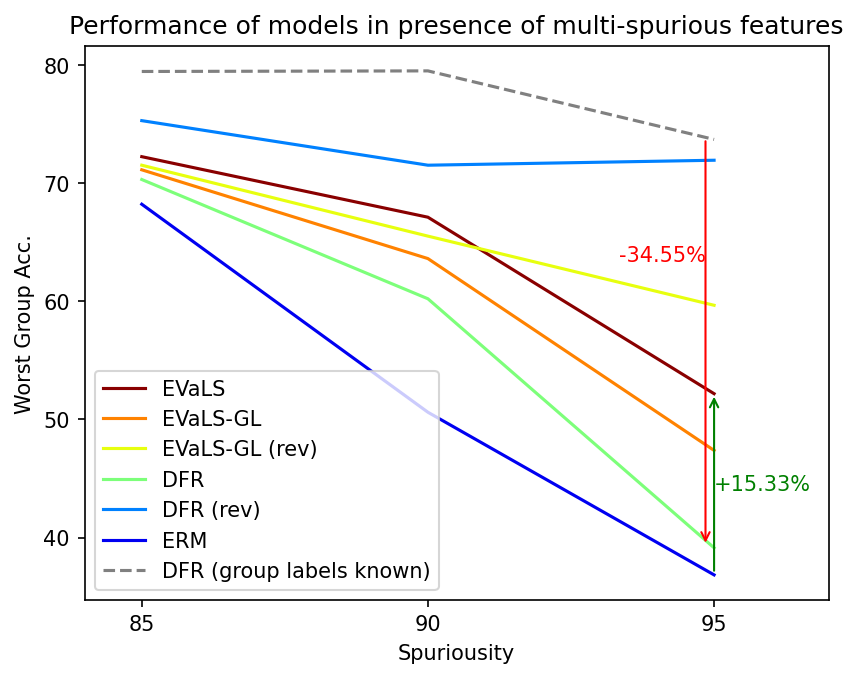

In [149]:
from matplotlib import pyplot as plt
# plt.figure(figsize=(8, 9))
plt.rcParams['figure.dpi'] = 150
plt.plot(s, Evals, label='EVaLS', color=plt.cm.jet(0.99))
plt.plot(s, Evalsgl, label='EVaLS-GL', color=plt.cm.jet(0.77))
plt.plot(s, Evalsgl_rev, label='EVaLS-GL (rev)', color=plt.cm.jet(0.63))
plt.plot(s, dfr, label='DFR', color=plt.cm.jet(0.5))
plt.plot(s, dfr_rev, label='DFR (rev)', color=plt.cm.jet(0.25))
plt.plot(s, erm, label='ERM', color=plt.cm.jet(0.1))
plt.plot(s, dfr_known, '--', color='gray', label='DFR (group labels known)')
plt.xticks(s)
plt.xlim([84, 97])
plt.xlabel('Spuriousity')
plt.ylabel('Worst Group Acc.')
plt.title('Performance of models in presence of multi-spurious features')
plt.annotate('', xy=(94.85, 39.2), xytext=(94.85, 73.88),
                 arrowprops=dict(arrowstyle='->', color='red'))
plt.text(94.85, (39.13 + 73.68)/2 + 7.5, f'-{73.68-39.13:.2f}%', ha='right', va='center', color='red')
plt.annotate('', xy=(95, 52.27), xytext=(95, 36.84),
                 arrowprops=dict(arrowstyle='->', color='green'))
plt.text(95, (36.84 + 52.17)/2, f'+{52.17-36.84:.2f}%', ha='left', va='center', color='green')
plt.legend()
plt.show()